In [1]:
# Step 1: Specify the path to the "experiment_analyses" folder in your system (after cloning the repo)
# This step is because I have a separate folder in the repo that contains the Jupyter Notebooks for organization purposes
import warnings
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

experiment_analyses_dir = r"C:\Users\graci\OneDrive\Documents\Github\driving_exp_1_analyses\experiment_analyses"  # Replace with your desired directory
# r"C:\Users\graci\Dropbox\PAndA\Thesis Experiment 1\scripts\experiment_analyses"  # Replace with your desired directory
os.chdir(experiment_analyses_dir)


# Step 2: Specify the location of file paths contain the main_data folder
# I will share a Dropbox folder with you that contains these folders, so you can just copy and paste your file system file path to these
# Note that the files in these folders should be treated as immutable
import preprocess

SUBJECT_PATH = "C:/Users/graci/Dropbox/PAndA/Thesis Experiment 3/data/main_data" 
# "C:/Users/graci/Dropbox/PAndA/Thesis Experiment 2/data/main_data" # Dropbox directory path that leads to the csv files for all subejcts across both familiar and unfamiliar group

# subject_dict: all keys are of each subject's id (e.g. "wad") and all values are of the subject_object (which will contain all the data for the subject)

warnings.filterwarnings("ignore")
subject_dict = preprocess.run(SUBJECT_PATH)
print('Success!')

def getCostMatrix(dist_mat):
    """
    Find minimum-cost path through matrix `dist_mat` using dynamic programming.

    The cost of a path is defined as the sum of the matrix entries on that
    path. See the following for details of the algorithm:

    - http://en.wikipedia.org/wiki/Dynamic_time_warping
    - https://www.ee.columbia.edu/~dpwe/resources/matlab/dtw/dp.m

    The notation in the first reference was followed, while Dan Ellis's code
    (second reference) was used to check for correctness. Returns a list of
    path indices and the cost matrix.
    """

    N, M = dist_mat.shape # Matrix of nxm shape

    # Initialize the cost matrix with first entry zero and infinity entries along edges -> |__
    cost_mat = np.zeros((N + 1, M + 1))
    for i in range(1, N + 1):
        cost_mat[i, 0] = np.inf
    for i in range(1, M + 1):
        cost_mat[0, i] = np.inf

    # Fill the cost matrix while keeping traceback information
    traceback_mat = np.zeros((N, M))
    for i in range(N):
        for j in range(M):
            penalty = [
                cost_mat[i, j],      # match (0)
                cost_mat[i, j + 1],  # insertion (1)
                cost_mat[i + 1, j]]  # deletion (2)
            i_penalty = np.argmin(penalty)
            cost_mat[i + 1, j + 1] = dist_mat[i, j] + penalty[i_penalty]
            traceback_mat[i, j] = i_penalty

    # Traceback from last entry back to first to get alignment path
    i = N - 1
    j = M - 1
    path = [(i, j)]
    while i > 0 or j > 0:
        tb_type = traceback_mat[i, j]
        if tb_type == 0:
            # Match
            i = i - 1
            j = j - 1
        elif tb_type == 1:
            # Insertion
            i = i - 1
        elif tb_type == 2:
            # Deletion
            j = j - 1
        path.append((i, j))

    # Strip infinity edges from cost_mat before returning
    cost_mat = cost_mat[1:, 1:]
    return (path[::-1], cost_mat) # Return path and cost_mat

Success!


In [2]:
from scipy.spatial.distance import cdist

# Define experimental groups and initialize average cost storage
control_group_ids = ["agony","both","cargo","cheek","cub","desk","dingy","fetch","final","floss","fried","mount","pagan","slot","snarl","spoof","tribe","untie","width","wish"]
scrambled_segments_group_ids = ["brave","comic","crop","dial","donor","even","gave","gore","gray","hump","jury","mud","outer","ozone","relax","riot","salon","unit","upon","zebra"]
scrambled_landmarks_group_ids = ["arena","chain","cloth","crept","disk","elm","flask","flip","game","grab","grant","guy","jam","line","marry","ounce","river","roar","shred","spoon"]

group_dict = {
    "control": control_group_ids,
    "scrambled_segments": scrambled_segments_group_ids,
    "scrambled_landmarks": scrambled_landmarks_group_ids
}

track_pieces = ['chicane','triple_s','symmetric_parabolic','traffic_circle',
                'asymmetric_parabolic_2','t_turn','asymmetric_parabolic_1','spiral']

average_costs = []

# Iterate over each group
for group_name, subject_ids in group_dict.items():
    print(f'\nProcessing group: {group_name}')
    group_cost = 0
    
    for subject_id in subject_ids:
        subject_object = subject_dict[subject_id]
        trial_object_ten = subject_object.trials[9]
        trial_object_eleven = subject_object.trials[10]

        track_piece_object_dict_ten = trial_object_ten.pieces
        track_piece_object_dict_eleven = trial_object_eleven.pieces

        subject_cost = 0
        for track_piece_id in track_pieces:
            # Retrieve trajectories
            trajectory_ten = track_piece_object_dict_ten[track_piece_id].trajectory_df[['pos_x', 'pos_z']].values
            trajectory_eleven = track_piece_object_dict_eleven[track_piece_id].trajectory_df[['pos_x', 'pos_z']].values

            # Compute cost
            dist_matrix = cdist(trajectory_ten, trajectory_eleven, 'euclidean')
            path, cost_matrix = getCostMatrix(dist_matrix)
            norm_cost = cost_matrix[-1, -1] / (cost_matrix.shape[0] * cost_matrix.shape[1])

            subject_cost += norm_cost
            print(f'{subject_id} ({track_piece_id}): norm_cost = {norm_cost:.4f}')
        
        group_cost += subject_cost / len(track_pieces)
    
    avg_group_cost = group_cost / len(subject_ids)
    average_costs.append(avg_group_cost)
    print(f'Average cost for {group_name}: {avg_group_cost:.4f}')

# Final result
print("\nAverage costs per group (in order of control, scrambled_segments, scrambled_landmarks):")
print(average_costs)



Processing group: control
agony (chicane): norm_cost = 0.0048
agony (triple_s): norm_cost = 0.0142
agony (symmetric_parabolic): norm_cost = 0.0038
agony (traffic_circle): norm_cost = 0.0146
agony (asymmetric_parabolic_2): norm_cost = 0.0173
agony (t_turn): norm_cost = 0.0038
agony (asymmetric_parabolic_1): norm_cost = 0.0083
agony (spiral): norm_cost = 0.0074
both (chicane): norm_cost = 0.0059
both (triple_s): norm_cost = 0.0572
both (symmetric_parabolic): norm_cost = 0.0443
both (traffic_circle): norm_cost = 0.0278
both (asymmetric_parabolic_2): norm_cost = 0.0349
both (t_turn): norm_cost = 0.0140
both (asymmetric_parabolic_1): norm_cost = 0.0303
both (spiral): norm_cost = 0.1674
cargo (chicane): norm_cost = 0.0033
cargo (triple_s): norm_cost = 0.0042
cargo (symmetric_parabolic): norm_cost = 0.0194
cargo (traffic_circle): norm_cost = 0.0233
cargo (asymmetric_parabolic_2): norm_cost = 0.0133
cargo (t_turn): norm_cost = 0.0073
cargo (asymmetric_parabolic_1): norm_cost = 0.0196
cargo (s

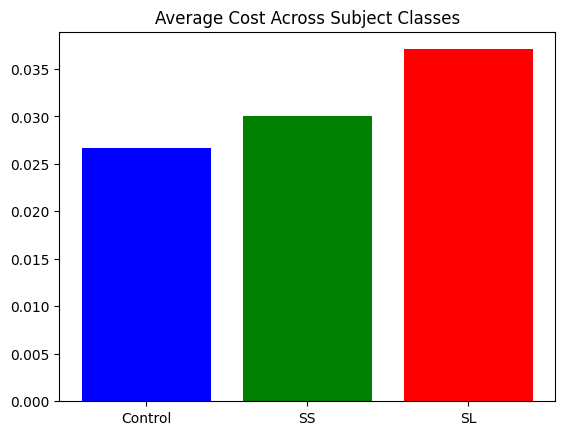

In [4]:
# Bar plot of average costs for each group
plt.bar(['Control', 'SS', 'SL'], average_costs, color = ['blue', 'green', 'red'])
plt.title('Average Cost Across Subject Classes')
plt.show()

In [5]:
plt.savefig('Average Cost Across Subject Classes.png')

<Figure size 640x480 with 0 Axes>